# Video Background - Foreground Decomposition: Truncated Singular Value Decomposition (Truncated SVD)

This notebook isolates **Truncated SVD** from the original messy pipeline and evaluates it cleanly on:

1. **Simulated data** - a synthetic surveillance video (controlled, known low-rank + sparse structure)
2. **Generalization data** - a real-world video, to test whether the same assumptions hold outside the synthetic benchmark

Truncated SVD is the simplest baseline: it finds the optimal low-rank approximation of the raw observation matrix using the least-squares approach, with no sparsity-promoting mechanism. It is included to show the limits of a naive low-rank approach before comparing against PCA and Robust PCA in the companion notebooks.


## 1. Setup

In [1]:
# ============================================================
# Imports
# ============================================================
import logging
import time
from dataclasses import dataclass, field
from pathlib import Path
from typing import List, NamedTuple, Optional, Tuple

import cv2
import numpy as np
import matplotlib.pyplot as plt

try:
    from skimage.metrics import structural_similarity as _ssim_fn
    _SKIMAGE_AVAILABLE = True
except ImportError:
    _SKIMAGE_AVAILABLE = False

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s",
    datefmt="%H:%M:%S",
)
log = logging.getLogger(__name__)

if not _SKIMAGE_AVAILABLE:
    log.warning("scikit-image not found - SSIM will be skipped. Install with: pip install scikit-image")


In [2]:
# ============================================================
# Configuration
#
# Fill in the two video paths below before running.
#   simulated_video_path : a synthetic / controlled benchmark video
#                           (e.g. BMC synth scenes) used as the main
#                           experiment.
#   real_video_path       : a real-world video used only to test
#                           generalization of the same pipeline.
#
# No ground truth is required or used anywhere in this notebook.
# ============================================================

@dataclass(frozen=True)
class Config:
    #input video paths
    simulated_video_path: Path = Path("/home/isha/Desktop/AI_ML_2026/Projects/Robust_PCA_Video_Decomposition/data/raw_data/111.mp4")
    real_video_path: Path = Path("/home/isha/Desktop/AI_ML_2026/Projects/Robust_PCA_Video_Decomposition/data/raw_data/Video_008.avi")

    #Output path
    outputs_dir: Path = Path("/home/isha/Desktop/AI_ML_2026/Projects/Robust_PCA_Video_Decomposition/outputs/v2/")

    #Frame preprocessing
    frame_width: int = 120
    frame_height: int = 90

    #Time window to extract (in seconds)
    start_second: float = 25.0
    end_second: float = 30.0
    frame_step: int = 1

    def __post_init__(self):
        self.outputs_dir.mkdir(parents=True, exist_ok=True)


CFG = Config()
log.info(
    "Config loaded: frame size=%dx%d | window=%.1fs-%.1fs",
    CFG.frame_height, CFG.frame_width, CFG.start_second, CFG.end_second,
)


15:57:35 - INFO - Config loaded: frame size=90x120 | window=25.0s-30.0s


In [3]:
# ============================================================
# Ground Truth Configuration
#
# The GT video contains binary foreground masks:
#   white (255) = foreground pixel
#   black (0)   = background pixel
#
# The same start_second / end_second window used for the
# observation matrix M is applied here, so GT and M are
# frame-aligned by construction.
# ============================================================

@dataclass(frozen=True)
class GTConfig:
    gt_video_path: Path = Path("/home/isha/Desktop/AI_ML_2026/Projects/Robust_PCA_Video_Decomposition/data/raw_data/111_gt.mp4")   

GT_CFG = GTConfig()
log.info("GT config loaded: %s", GT_CFG.gt_video_path)


15:57:35 - INFO - GT config loaded: /home/isha/Desktop/AI_ML_2026/Projects/Robust_PCA_Video_Decomposition/data/raw_data/111_gt.mp4


## 2. Frame Extraction Utilities

Shared by both the simulated and real-data runs below, so results are directly comparable.

In [4]:
# ============================================================
# Frame extraction utilities
#
# Converts a video file into an observation matrix M of shape
# (n_pixels, n_frames). Each column is one flattened, grayscale,
# [0,1]-normalized frame. Used identically for both the simulated
# and the real video, so results are directly comparable.
# ============================================================

def preprocess_frame(frame_bgr: np.ndarray, h: int, w: int) -> np.ndarray:
    """BGR frame -> normalized grayscale column vector."""
    gray = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2GRAY)
    resized = cv2.resize(gray, (w, h), interpolation=cv2.INTER_AREA)
    return (resized.astype(np.float32).flatten() / 255.0)


def extract_frames(
    video_path: Path,
    cfg: Config,
    cache_name: Optional[str] = None,
) -> np.ndarray:
    """
    Extracts frames from [start_second, end_second] of video_path into
    an observation matrix M, shape (n_pixels, n_frames), float32, [0,1].

    Caches the result to cfg.outputs_dir / cache_name (if given) so
    repeated runs don't re-decode the video.
    """
    if not video_path.exists():
        raise FileNotFoundError(
            f"Video not found: {video_path}\n"
            f"Edit CFG.simulated_video_path / CFG.real_video_path to point "
            f"at a real file before running this cell."
        )

    cache_path = cfg.outputs_dir / cache_name if cache_name else None
    if cache_path is not None and cache_path.exists():
        M = np.load(cache_path)
        log.info("Loaded cached matrix: %s | shape=%s", cache_path.name, M.shape)
        return M

    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise RuntimeError(f"Failed to open video: {video_path}")

    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    duration = total_frames / fps if fps else 0.0

    log.info(
        "Video opened: %s | fps=%.2f | total_frames=%d | duration=%.1fs",
        video_path.name, fps, total_frames, duration,
    )

    start_frame = int(cfg.start_second * fps)
    end_frame = int(cfg.end_second * fps)

    if start_frame >= total_frames:
        raise ValueError(
            f"start_second={cfg.start_second}s -> frame {start_frame} "
            f"exceeds video length ({total_frames} frames, {duration:.1f}s)"
        )
    if end_frame > total_frames:
        log.warning("end_second exceeds video length. Clamping to %d frames.", total_frames)
        end_frame = total_frames

    cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)

    columns = []
    frame_idx = start_frame
    while frame_idx < end_frame:
        ret, frame = cap.read()
        if not ret:
            log.warning("Stream ended early at frame %d.", frame_idx)
            break
        if (frame_idx - start_frame) % cfg.frame_step == 0:
            columns.append(preprocess_frame(frame, cfg.frame_height, cfg.frame_width))
        frame_idx += 1
    cap.release()

    if not columns:
        raise RuntimeError("No frames extracted. Check start_second/end_second and the video file.")

    M = np.column_stack(columns).astype(np.float32)
    M = np.clip(M, 0.0, 1.0)

    if cache_path is not None:
        np.save(cache_path, M)
        log.info("Matrix cached: %s | shape=%s | %.1f MB", cache_path.name, M.shape, M.nbytes / 1e6)

    log.info("Extracted matrix: shape=%s | dtype=%s", M.shape, M.dtype)
    return M


def inspect_matrix(M: np.ndarray, cfg: Config, title: str = "Observation Matrix") -> None:
    """Logs basic stats and plots sample frames + singular value spectrum."""
    log.info("=" * 50)
    log.info("%s | shape=%s | dtype=%s", title, M.shape, M.dtype)
    log.info("Min/max: %.4f / %.4f | Mean/std: %.4f / %.4f", M.min(), M.max(), M.mean(), M.std())

    k = min(1000, M.shape[1])
    _, s, _ = np.linalg.svd(M[:, :k], full_matrices=False)
    explained = np.cumsum(s ** 2) / np.sum(s ** 2)
    rank_90 = int(np.searchsorted(explained, 0.90)) + 1
    rank_99 = int(np.searchsorted(explained, 0.99)) + 1
    log.info("Estimated rank (90%% variance): %d | (99%% variance): %d", rank_90, rank_99)
    log.info("=" * 50)

    n_show = min(5, M.shape[1])
    indices = np.linspace(0, M.shape[1] - 1, n_show, dtype=int)
    fig, axes = plt.subplots(1, n_show, figsize=(3 * n_show, 3))
    if n_show == 1:
        axes = [axes]
    fig.suptitle(f"{title}: Sample Frames", fontsize=12)
    for ax, idx in zip(axes, indices):
        frame = M[:, idx].reshape(cfg.frame_height, cfg.frame_width)
        ax.imshow(frame, cmap="gray", vmin=0, vmax=1)
        ax.set_title(f"Frame {idx}", fontsize=9)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].plot(s[:10], "o-", color="steelblue", markersize=4)
    axes[0].set_title("Top 10 Singular Values")
    axes[0].set_xlabel("Index")
    axes[0].set_ylabel("Singular value")
    axes[0].grid(alpha=0.3)

    axes[1].plot(explained[:30], "s-", color="darkorange", markersize=4)
    axes[1].axhline(0.90, color="red", linestyle="--", label="90%")
    axes[1].axhline(0.99, color="gray", linestyle="--", label="99%")
    axes[1].set_title("Cumulative Explained Variance")
    axes[1].set_xlabel("Number of components")
    axes[1].set_ylabel("Cumulative variance ratio")
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


## Method: Truncated SVD (Eckart–Young baseline)

Truncated SVD finds the best rank-$k$ approximation of $M$ using the least-squares:

$$
\min_{L} \; \|M - L\|_F \quad \text{s.t.} \quad \operatorname{rank}(L) \le k
$$

By the **Eckart–Young theorem**, the closed-form solution is built directly from the SVD of $M = U\Sigma V^T$:

$$
L = U_k \Sigma_k V_k^T, \qquad S = M - L
$$

- $L$ (rank-$k$) is treated as the **background** estimate.
- $S$ (the residual) is treated as the **foreground** estimate.

This is *not* a robust decomposition, it minimizes overall reconstruction error but has no mechanism
to push $S$ towards sparsity. Moving objects often "leak" into $L$ as ghosting, and $S$ picks up
background noise as well as real foreground. It is included here as the simplest possible baseline.


In [5]:
# ============================================================
# Truncated SVD baseline
#
#   min_L ||M - L||_F   s.t. rank(L) <= k
#   Closed-form solution: L = U_k @ Sigma_k @ Vt_k   (Eckart-Young)
#   S = M - L
# ============================================================

class SVDResult(NamedTuple):
    L: np.ndarray
    S: np.ndarray
    singular_values: np.ndarray
    rank_used: int
    runtime_sec: float


def truncated_svd(M: np.ndarray, k: int) -> SVDResult:
    """Decomposes M into a rank-k background L and residual S via truncated SVD."""
    assert M.ndim == 2, "M must be a 2D matrix"
    assert 1 <= k <= min(M.shape), f"k={k} out of valid range [1, {min(M.shape)}]"

    t0 = time.perf_counter()
    U, s, Vt = np.linalg.svd(M, full_matrices=False)

    U_k, s_k, Vt_k = U[:, :k], s[:k], Vt[:k, :]
    L = (U_k * s_k) @ Vt_k
    S = M - L

    L = np.clip(L, 0.0, 1.0).astype(np.float32)
    S = np.clip(S, 0.0, 1.0).astype(np.float32)
    runtime = time.perf_counter() - t0

    frob = np.linalg.norm(M - L, "fro") / np.linalg.norm(M, "fro")
    log.info("Truncated SVD | rank=%d | Frobenius error=%.4f | time=%.2fs", k, frob, runtime)

    return SVDResult(L=L, S=S, singular_values=s, rank_used=k, runtime_sec=runtime)


In [6]:
# ============================================================
# Visualization: Original / Background / Foreground grid
# ============================================================

def visualize_svd_result(result: SVDResult, M: np.ndarray, cfg: Config, frame_indices: Optional[List[int]] = None) -> None:
    if frame_indices is None:
        n = M.shape[1]
        frame_indices = sorted(set([0, n // 4, n // 2, 3 * n // 4]))

    n_show = len(frame_indices)
    fig, axes = plt.subplots(3, n_show, figsize=(3.2 * n_show, 8))
    if n_show == 1:
        axes = axes.reshape(3, 1)
    fig.suptitle(f"Truncated SVD (rank={result.rank_used})", fontsize=13, fontweight="bold")

    row_labels = ["Original M", "Background L (SVD)", "Foreground S (SVD)"]
    sources = [M, result.L, result.S]

    for row, (label, source) in enumerate(zip(row_labels, sources)):
        for col, idx in enumerate(frame_indices):
            frame = source[:, idx].reshape(cfg.frame_height, cfg.frame_width)
            axes[row, col].imshow(frame, cmap="gray", vmin=0, vmax=1)
            axes[row, col].set_title(f"Frame {idx}", fontsize=9)
            axes[row, col].axis("off")
        axes[row, 0].set_ylabel(label, fontsize=10, fontweight="bold")
        axes[row, 0].axis("on")
        axes[row, 0].tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

    plt.tight_layout()
    plt.show()


def run_svd_rank_sweep(M: np.ndarray, cfg: Config, ranks: List[int] = (1, 3, 5)) -> dict:
    """Runs truncated SVD at several ranks and visualizes each, to show the
    background-vs-ghosting trade-off as k increases."""
    results = {}
    log.info("Running SVD rank sweep: %s", list(ranks))
    for k in ranks:
        results[k] = truncated_svd(M, k)

    log.info("-" * 55)
    log.info("%-8s %-20s %-15s", "rank k", "Frobenius error", "runtime (s)")
    log.info("-" * 55)
    for k, r in results.items():
        frob = np.linalg.norm(M - r.L, "fro") / np.linalg.norm(M, "fro")
        log.info("%-8d %-20.4f %-15.3f", k, frob, r.runtime_sec)

    for k, r in results.items():
        visualize_svd_result(r, M, cfg)

    return results


## 3. Metrics

This notebook computes two independent groups of metrics:

**Group 1 - Reconstruction metrics** (L vs Frame 0 of M as proxy background reference): Frobenius error, MSE, PSNR, SSIM.  These are retained from the original pipeline and measure background reconstruction fidelity.

**Group 2 - GT detection metrics** (binarised S vs binary GT mask G): Precision, Recall, F1, Specificity.  These directly measure foreground isolation accuracy against the ground-truth foreground mask.

See the compatibility note cell for why both groups are kept.

In [7]:
# ============================================================
# Metrics  (no ground truth available)
#
# All metrics compare the reconstructed background L against a
# single reference column: Frame 0 of the observation matrix M.
# This is a proxy for a "clean background" frame, NOT a true
# ground truth. Interpret accordingly:
#
#   - Frobenius error : ||M - L||_F / ||M||_F  (overall reconstruction)
#   - MSE / PSNR / SSIM : per-frame quality of L vs. reference frame,
#     averaged over all frames.
# ============================================================

from typing import NamedTuple


class MetricsResult(NamedTuple):
    frobenius_error: float
    mse: float
    psnr_db: float
    ssim: Optional[float]


def frobenius_error(M: np.ndarray, L: np.ndarray) -> float:
    """Relative Frobenius reconstruction error: ||M - L||_F / ||M||_F."""
    assert M.shape == L.shape, f"Shape mismatch: M={M.shape}, L={L.shape}"
    norm_M = np.linalg.norm(M, "fro")
    if norm_M == 0:
        raise ValueError("M is the zero matrix - Frobenius error undefined.")
    return float(np.linalg.norm(M - L, "fro") / norm_M)


def mse_frame(reference: np.ndarray, estimate: np.ndarray) -> float:
    """Mean squared error between two equally-shaped arrays."""
    assert reference.shape == estimate.shape
    return float(np.mean((reference.astype(np.float64) - estimate.astype(np.float64)) ** 2))


def mse_matrix(reference_col: np.ndarray, L: np.ndarray) -> float:
    """Mean MSE across all columns of L vs. a single reference column."""
    values = [mse_frame(reference_col, L[:, j]) for j in range(L.shape[1])]
    return float(np.mean(values))


def psnr_frame(reference: np.ndarray, estimate: np.ndarray, max_val: float = 1.0) -> float:
    """PSNR (dB) between two equally-shaped arrays."""
    mse = mse_frame(reference, estimate)
    if mse == 0.0:
        return float("inf")
    return float(10.0 * np.log10(max_val ** 2 / mse))


def psnr_matrix(reference_col: np.ndarray, L: np.ndarray) -> float:
    """Mean PSNR across all columns of L vs. a single reference column."""
    values = [psnr_frame(reference_col, L[:, j]) for j in range(L.shape[1])]
    finite = [v for v in values if np.isfinite(v)]
    return float(np.mean(finite)) if finite else float("inf")


def ssim_frame(reference: np.ndarray, estimate: np.ndarray, cfg: Config) -> Optional[float]:
    """SSIM between two flattened frames, reshaped to (H, W). None if skimage missing."""
    if not _SKIMAGE_AVAILABLE:
        return None
    ref_2d = reference.reshape(cfg.frame_height, cfg.frame_width).astype(np.float64)
    est_2d = estimate.reshape(cfg.frame_height, cfg.frame_width).astype(np.float64)
    return float(_ssim_fn(ref_2d, est_2d, data_range=1.0))


def ssim_matrix(reference_col: np.ndarray, L: np.ndarray, cfg: Config) -> Optional[float]:
    """Mean SSIM across all columns of L vs. a single reference column."""
    if not _SKIMAGE_AVAILABLE:
        return None
    values = [ssim_frame(reference_col, L[:, j], cfg) for j in range(L.shape[1])]
    return float(np.mean(values))


def compute_metrics(M: np.ndarray, L: np.ndarray, cfg: Config, label: str = "") -> MetricsResult:
    """Computes Frobenius error, MSE, PSNR and SSIM of L vs. Frame 0 of M."""
    reference_col = M[:, 0]

    frob = frobenius_error(M, L)
    mse_val = mse_matrix(reference_col, L)
    psnr_val = psnr_matrix(reference_col, L)
    ssim_val = ssim_matrix(reference_col, L, cfg)

    log.info("-" * 55)
    log.info("Metrics%s", f" [{label}]" if label else "")
    log.info("  Frobenius error : %.6f", frob)
    log.info("  MSE             : %.6f", mse_val)
    log.info("  PSNR            : %.2f dB", psnr_val)
    log.info("  SSIM            : %s", f"{ssim_val:.4f}" if ssim_val is not None else "N/A (scikit-image missing)")
    log.info("-" * 55)

    return MetricsResult(frobenius_error=frob, mse=mse_val, psnr_db=psnr_val, ssim=ssim_val)


In [8]:
# ============================================================
# Metric Compatibility Note
#
# Two independent groups of metrics are computed in this notebook:
#
# GROUP 1 — Reconstruction metrics (retained from previous version):
#   Frobenius error : ||M - L||_F / ||M||_F
#   MSE, PSNR, SSIM : quality of recovered background L vs Frame 0 of M
#
#   These compare L against Frame 0 of M used as a proxy background
#   reference. They measure how well the method reconstructs a clean
#   background, but are self-referential (Frame 0 is not a true GT).
#   They are kept because:
#     a) They are standard image-quality metrics interpretable on their own.
#     b) They allow comparison between SVD / PCA / RPCA on background
#        reconstruction fidelity, where RPCA is expected to score lower
#        on Frobenius/MSE/PSNR (it doesn't optimise these) but produce
#        a visually cleaner background.
#
# GROUP 2 - GT detection metrics (new):
#   Precision, Recall, F1, Specificity : quality of recovered foreground S
#   vs the binary GT mask G, after Otsu binarisation of S.
#
#   These directly measure foreground isolation accuracy and are the
#   standard metrics used in the background subtraction literature
#   (CDnet, BMC 2012 benchmarks). RPCA is expected to outperform SVD
#   and PCA here because it explicitly promotes sparsity in S.
#
# The two groups are NOT directly comparable to each other - they
# measure different outputs (L vs S) against different references
# (Frame 0 proxy vs binary GT mask).
# ============================================================
print("Metric compatibility note: see cell comments above.")


Metric compatibility note: see cell comments above.


In [9]:
# ============================================================
# Ground Truth Loader
#
# Extracts the GT mask video into a binary matrix G of shape
# (n_pixels, n_frames), dtype uint8, values in {0, 1}.
#
# The same time window (start_second, end_second) and frame
# size (frame_height, frame_width) as the observation matrix M
# are used, so columns of G align 1-to-1 with columns of M.
# ============================================================

def extract_gt_frames(
    gt_video_path: Path,
    cfg: Config,
    cache_name: Optional[str] = None,
    target_n_frames: Optional[int] = None,
) -> np.ndarray:
    """
    Extracts ground-truth foreground masks into a binary matrix G,
    shape (n_pixels, n_frames), dtype uint8, values in {0, 1}.

    The GT video is assumed to have white (>=128) pixels for foreground
    and black (<128) pixels for background.

    If target_n_frames is provided (pass M.shape[1]), G is trimmed or
    zero-padded along the frame axis so that G.shape[1] == target_n_frames,
    guaranteeing it can be compared directly with the observation matrix M.
    """
    if not gt_video_path.exists():
        raise FileNotFoundError(
            f"GT video not found: {gt_video_path}\n"
            f"Edit GT_CFG.gt_video_path before running this cell."
        )

    cache_path = cfg.outputs_dir / cache_name if cache_name else None
    if cache_path is not None and cache_path.exists():
        G = np.load(cache_path)
        log.info("Loaded cached GT matrix: %s | shape=%s", cache_path.name, G.shape)
        # Still align to target even when loading from cache
        if target_n_frames is not None and G.shape[1] != target_n_frames:
            G = _align_gt_frames(G, target_n_frames)
        return G

    cap = cv2.VideoCapture(str(gt_video_path))
    if not cap.isOpened():
        raise RuntimeError(f"Failed to open GT video: {gt_video_path}")

    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    log.info("GT video: fps=%.2f | total_frames=%d", fps, total_frames)

    start_frame = int(cfg.start_second * fps)
    end_frame   = min(int(cfg.end_second * fps), total_frames)
    cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)

    columns = []
    frame_idx = start_frame
    while frame_idx < end_frame:
        ret, frame = cap.read()
        if not ret:
            break
        if (frame_idx - start_frame) % cfg.frame_step == 0:
            gray    = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            resized = cv2.resize(gray, (cfg.frame_width, cfg.frame_height),
                                 interpolation=cv2.INTER_NEAREST)
            binary  = (resized >= 128).astype(np.uint8).flatten()
            columns.append(binary)
        frame_idx += 1
    cap.release()

    if not columns:
        raise RuntimeError("No GT frames extracted. Check video path and time window.")

    G = np.column_stack(columns)   # shape (n_pixels, n_frames), values {0,1}

    # Align frame count to observation matrix if requested
    if target_n_frames is not None and G.shape[1] != target_n_frames:
        G = _align_gt_frames(G, target_n_frames)

    if cache_path is not None:
        np.save(cache_path, G)
        log.info("GT matrix cached: %s | shape=%s", cache_path.name, G.shape)

    log.info("GT matrix extracted: shape=%s | foreground fraction=%.4f",
             G.shape, G.mean())
    return G


def _align_gt_frames(G: np.ndarray, target_n: int) -> np.ndarray:
    """
    Trim or zero-pad G along the frame axis to reach exactly target_n columns.
    Trimming drops excess trailing frames; padding appends all-zero (background)
    columns.  A warning is logged so the mismatch is visible at runtime.
    """
    n = G.shape[1]
    if n > target_n:
        log.warning(
            "GT has %d frames but observation matrix has %d - "
            "trimming %d trailing GT frames.", n, target_n, n - target_n
        )
        return G[:, :target_n]
    else:
        log.warning(
            "GT has %d frames but observation matrix has %d - "
            "padding GT with %d all-background columns.", n, target_n, target_n - n
        )
        pad = np.zeros((G.shape[0], target_n - n), dtype=G.dtype)
        return np.concatenate([G, pad], axis=1)


def inspect_gt(G: np.ndarray, M: np.ndarray, cfg: Config) -> None:
    """Sanity-check: overlays GT mask on a sample of original frames."""
    if G.shape != M.shape:
        log.warning(
            "GT shape %s does not match M shape %s after alignment - "
            "this should not happen; check extract_gt_frames call.",
            G.shape, M.shape,
        )
        # Align here as a last-resort safety net
        G = _align_gt_frames(G, M.shape[1])
    n = G.shape[1]
    indices = np.linspace(0, n - 1, min(5, n), dtype=int)

    fig, axes = plt.subplots(2, len(indices), figsize=(3 * len(indices), 5))
    fig.suptitle("Ground Truth Sanity Check: Original vs. GT Mask", fontsize=11)
    for col, idx in enumerate(indices):
        frame = M[:, idx].reshape(cfg.frame_height, cfg.frame_width)
        mask  = G[:, idx].reshape(cfg.frame_height, cfg.frame_width)
        axes[0, col].imshow(frame, cmap="gray", vmin=0, vmax=1)
        axes[0, col].set_title(f"Frame {idx}", fontsize=9)
        axes[0, col].axis("off")
        axes[1, col].imshow(mask, cmap="gray", vmin=0, vmax=1)
        axes[1, col].set_title("GT mask", fontsize=9)
        axes[1, col].axis("off")
    axes[0, 0].set_ylabel("Original", fontsize=9, fontweight="bold")
    axes[1, 0].set_ylabel("GT", fontsize=9, fontweight="bold")
    plt.tight_layout()
    plt.show()
    log.info("GT shape matches M. Foreground fraction: %.4f", G.mean())


In [10]:
# ============================================================
# Ground-Truth Metrics
#
# The recovered foreground S is continuous-valued in [0,1].
# To compare against the binary GT mask G we binarise S using
# Otsu's method - computed globally across all frames so the
# threshold is consistent and not tuned per-frame.
#
# Metrics computed per frame then averaged:
#   Precision   = TP / (TP + FP)   -- of predicted FG, how many correct
#   Recall      = TP / (TP + FN)   -- of true FG, how many found
#   F1          = 2 * P*R / (P+R)  -- harmonic mean (primary summary)
#   Specificity = TN / (TN + FP)   -- correct background rejection
#   Accuracy    = (TP + TN) / (TP + TN + FP + FN)  -- overall pixel correctness
#
# Frobenius error, MSE, PSNR, SSIM (from the previous metrics cell)
# compare L vs Frame 0 of M - a proxy for background quality.
# GT metrics compare binarised S vs G - a direct measure of
# foreground detection accuracy.  Both sets are retained because
# they measure different things: the former measures reconstruction
# fidelity of L; the latter measures detection quality of S.
# ============================================================

from typing import NamedTuple

class GTMetricsResult(NamedTuple):
    threshold:   float
    precision:   float
    recall:      float
    f1:          float
    specificity: float
    accuracy:    float


def otsu_threshold_global(S: np.ndarray) -> float:
    """
    Compute a single Otsu threshold across all columns of S
    (treated as one long 1-D signal), so the binarisation is
    consistent across frames and not tuned per-frame.
    """
    flat = (S.flatten() * 255).astype(np.uint8)
    thresh, _ = cv2.threshold(flat, 0, 255,
                              cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return float(thresh) / 255.0


def binarise_S(S: np.ndarray, threshold: float) -> np.ndarray:
    """Returns binary foreground matrix: 1 where S > threshold, else 0."""
    return (S > threshold).astype(np.uint8)


def _detection_metrics_frame(gt_col: np.ndarray,
                              pred_col: np.ndarray) -> dict:
    """Per-frame TP/FP/FN/TN and derived metrics."""
    tp = int(np.sum((pred_col == 1) & (gt_col == 1)))
    fp = int(np.sum((pred_col == 1) & (gt_col == 0)))
    fn = int(np.sum((pred_col == 0) & (gt_col == 1)))
    tn = int(np.sum((pred_col == 0) & (gt_col == 0)))

    precision   = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall      = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1          = (2 * precision * recall / (precision + recall)
                   if (precision + recall) > 0 else 0.0)
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    accuracy    = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0.0
    return dict(precision=precision, recall=recall,
                f1=f1, specificity=specificity, accuracy=accuracy)


def compute_gt_metrics(S: np.ndarray, G: np.ndarray,
                       label: str = "") -> GTMetricsResult:
    """
    Binarises S with a global Otsu threshold, then computes
    per-frame Precision, Recall, F1, and Specificity vs GT mask G,
    returning their mean across all frames.
    """
    assert S.shape == G.shape, (
        f"S shape {S.shape} != G shape {G.shape}"
    )
    threshold = otsu_threshold_global(S)
    S_bin     = binarise_S(S, threshold)

    frame_results = [
        _detection_metrics_frame(G[:, j], S_bin[:, j])
        for j in range(S.shape[1])
    ]

    precision   = float(np.mean([r["precision"]   for r in frame_results]))
    recall      = float(np.mean([r["recall"]      for r in frame_results]))
    f1          = float(np.mean([r["f1"]          for r in frame_results]))
    specificity = float(np.mean([r["specificity"] for r in frame_results]))
    accuracy    = float(np.mean([r["accuracy"]    for r in frame_results]))

    log.info("=" * 55)
    log.info("GT Metrics%s", f" [{label}]" if label else "")
    log.info("  Otsu threshold : %.4f", threshold)
    log.info("  Precision      : %.4f", precision)
    log.info("  Recall         : %.4f", recall)
    log.info("  F1-score       : %.4f", f1)
    log.info("  Specificity    : %.4f", specificity)
    log.info("  Accuracy       : %.4f", accuracy)
    log.info("=" * 55)

    return GTMetricsResult(threshold=threshold, precision=precision,
                           recall=recall, f1=f1, specificity=specificity,
                           accuracy=accuracy)


In [11]:
# ============================================================
# Ground Truth Visualisation
#
# Shows - for a sample of frames - the original frame, the
# recovered foreground S (continuous), the binarised S hat,
# and the GT mask G side by side.
# ============================================================

def visualize_gt_comparison(
    S: np.ndarray,
    G: np.ndarray,
    gt_result: GTMetricsResult,
    cfg: Config,
    title: str = "Foreground Detection vs. Ground Truth",
    frame_indices: Optional[List[int]] = None,
) -> None:
    """4-row grid: continuous S | binarised S | GT mask | difference map."""
    if frame_indices is None:
        n = S.shape[1]
        frame_indices = sorted(set([0, n // 4, n // 2, 3 * n // 4]))

    S_bin = binarise_S(S, gt_result.threshold)
    n_show = len(frame_indices)

    fig, axes = plt.subplots(4, n_show, figsize=(3.2 * n_show, 10))
    if n_show == 1:
        axes = axes.reshape(4, 1)
    fig.suptitle(
        f"{title}\n"
        #f"Otsu threshold={gt_result.threshold:.3f} | "
        f"Precision={gt_result.precision:.3f} | "
        f"Recall={gt_result.recall:.3f} | "
        f"F1={gt_result.f1:.3f}",
        fontsize=11, fontweight="bold",
    )

    row_labels = [
        "Foreground S (raw)",
        f"S binarised (τ={gt_result.threshold:.3f})",
        "GT mask G",
        "Difference (FP=red, FN=blue)",
    ]

    for col, idx in enumerate(frame_indices):
        s_raw  = S[:, idx].reshape(cfg.frame_height, cfg.frame_width)
        s_bin  = S_bin[:, idx].reshape(cfg.frame_height, cfg.frame_width)
        gt     = G[:, idx].reshape(cfg.frame_height, cfg.frame_width)

        # Difference image: FP = red, FN = blue, TP = white, TN = black
        diff_rgb = np.zeros((cfg.frame_height, cfg.frame_width, 3), dtype=np.float32)
        diff_rgb[(s_bin == 1) & (gt == 1)] = [1, 1, 1]   # TP white
        diff_rgb[(s_bin == 1) & (gt == 0)] = [1, 0, 0]   # FP red
        diff_rgb[(s_bin == 0) & (gt == 1)] = [0, 0, 1]   # FN blue

        for row, (img, cmap, vmin, vmax) in enumerate([
            (s_raw,    "gray",  0, 1),
            (s_bin,    "gray",  0, 1),
            (gt,       "gray",  0, 1),
            (diff_rgb, None,    None, None),
        ]):
            ax = axes[row, col]
            if cmap:
                ax.imshow(img, cmap=cmap, vmin=vmin, vmax=vmax)
            else:
                ax.imshow(img)
            ax.set_title(f"Frame {idx}", fontsize=9)
            ax.axis("off")

        axes[0, col].set_title(f"Frame {idx}", fontsize=9)

    for row, label in enumerate(row_labels):
        axes[row, 0].set_ylabel(label, fontsize=9, fontweight="bold")
        axes[row, 0].axis("on")
        axes[row, 0].tick_params(left=False, bottom=False,
                                 labelleft=False, labelbottom=False)
    plt.tight_layout()
    plt.show()


In [12]:
# ============================================================
# Plot: Simulated vs. Generalization metrics, side by side
#
# PSNR lives on a much larger numeric scale (dB) than Frobenius error / MSE / SSIM ([0,1])
# ============================================================

def plot_metrics_comparison(sim_metrics: MetricsResult, real_metrics: MetricsResult, cfg: Config) -> None:
    """
    Bar charts comparing Truncated SVD metrics between the simulated run
    and the real-data (generalization) run. PSNR is split into its own
    subplot since its scale dwarfs the other metrics.
    """
    small_entries = [
        ("Frobenius\nerror", sim_metrics.frobenius_error, real_metrics.frobenius_error, False),
        ("MSE", sim_metrics.mse, real_metrics.mse, False),
    ]
    if sim_metrics.ssim is not None and real_metrics.ssim is not None:
        small_entries.append(("SSIM", sim_metrics.ssim, real_metrics.ssim, True))

    psnr_entry = ("PSNR (dB)", sim_metrics.psnr_db, real_metrics.psnr_db, True)

    fig, axes = plt.subplots(1, 2, figsize=(11, 5), gridspec_kw={"width_ratios": [len(small_entries), 1]})

    def _draw(ax, entries, title):
        labels = [e[0] for e in entries]
        sim_vals = [e[1] for e in entries]
        real_vals = [e[2] for e in entries]
        higher_wins = [e[3] for e in entries]

        x = np.arange(len(entries))
        width = 0.35
        bars_sim = ax.bar(x - width / 2, sim_vals, width, label="Simulated", color="steelblue", alpha=0.85)
        bars_real = ax.bar(x + width / 2, real_vals, width, label="Real (generalization)", color="darkorange", alpha=0.85)

        for bar in list(bars_sim) + list(bars_real):
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width() / 2, h, f"{h:.3f}", ha="center", va="bottom", fontsize=8)

        tick_labels = [f"{lbl}\n{'↑ higher better' if hw else '↓ lower better'}" for lbl, hw in zip(labels, higher_wins)]
        ax.set_xticks(x)
        ax.set_xticklabels(tick_labels, fontsize=9)
        ax.set_title(title, fontsize=11)
        ax.grid(axis="y", linestyle="--", alpha=0.4)

    _draw(axes[0], small_entries, "Reconstruction / Similarity Metrics")
    _draw(axes[1], [psnr_entry], "PSNR (separate scale)")
    axes[0].set_ylabel("Metric value")
    axes[0].legend(fontsize=9)

    fig.suptitle("Truncated SVD: Simulated vs. Generalization Metrics", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()


## 4. Run on Simulated Data

15:57:35 - INFO - Loaded cached matrix: M_simulated.npy | shape=(10800, 125)
15:57:35 - INFO - ==================================================
15:57:35 - INFO - Simulated Data - Observation Matrix M | shape=(10800, 125) | dtype=float32
15:57:35 - INFO - Min/max: 0.0824 / 0.9647 | Mean/std: 0.3760 / 0.1230
15:57:35 - INFO - Estimated rank (90% variance): 1 | (99% variance): 1
15:57:35 - INFO - ==================================================


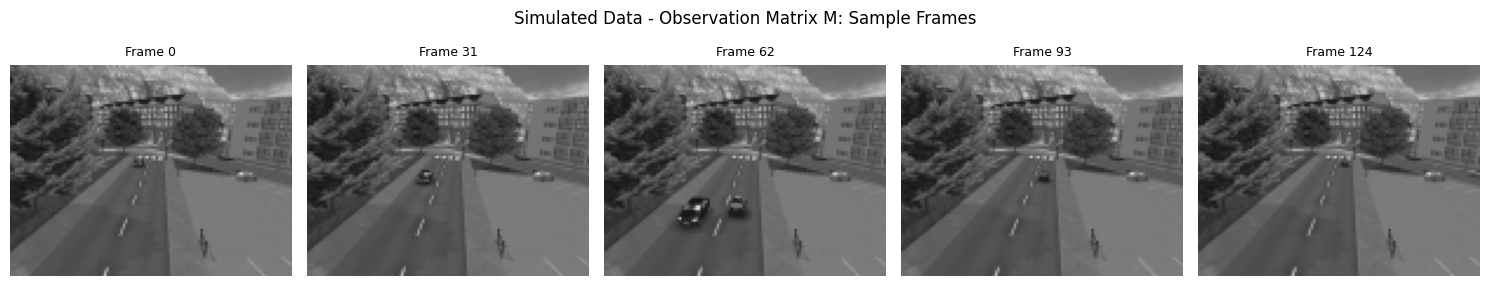

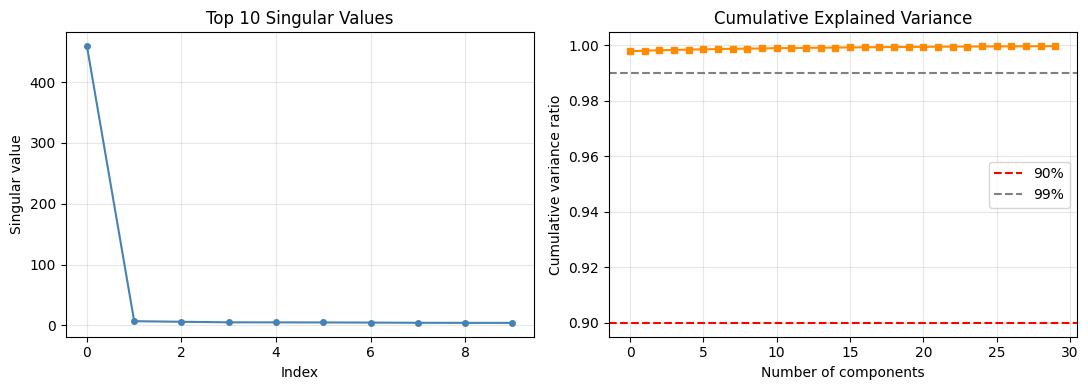

In [13]:
M_sim = extract_frames(CFG.simulated_video_path, CFG, cache_name="M_simulated.npy")
inspect_matrix(M_sim, CFG, title="Simulated Data - Observation Matrix M")


15:57:35 - INFO - Running SVD rank sweep: [1, 3, 5]
15:57:36 - INFO - Truncated SVD | rank=1 | Frobenius error=0.0470 | time=0.10s
15:57:36 - INFO - Truncated SVD | rank=3 | Frobenius error=0.0428 | time=0.07s
15:57:36 - INFO - Truncated SVD | rank=5 | Frobenius error=0.0400 | time=0.07s
15:57:36 - INFO - -------------------------------------------------------
15:57:36 - INFO - rank k   Frobenius error      runtime (s)    
15:57:36 - INFO - -------------------------------------------------------
15:57:36 - INFO - 1        0.0470               0.098          
15:57:36 - INFO - 3        0.0428               0.068          
15:57:36 - INFO - 5        0.0400               0.067          


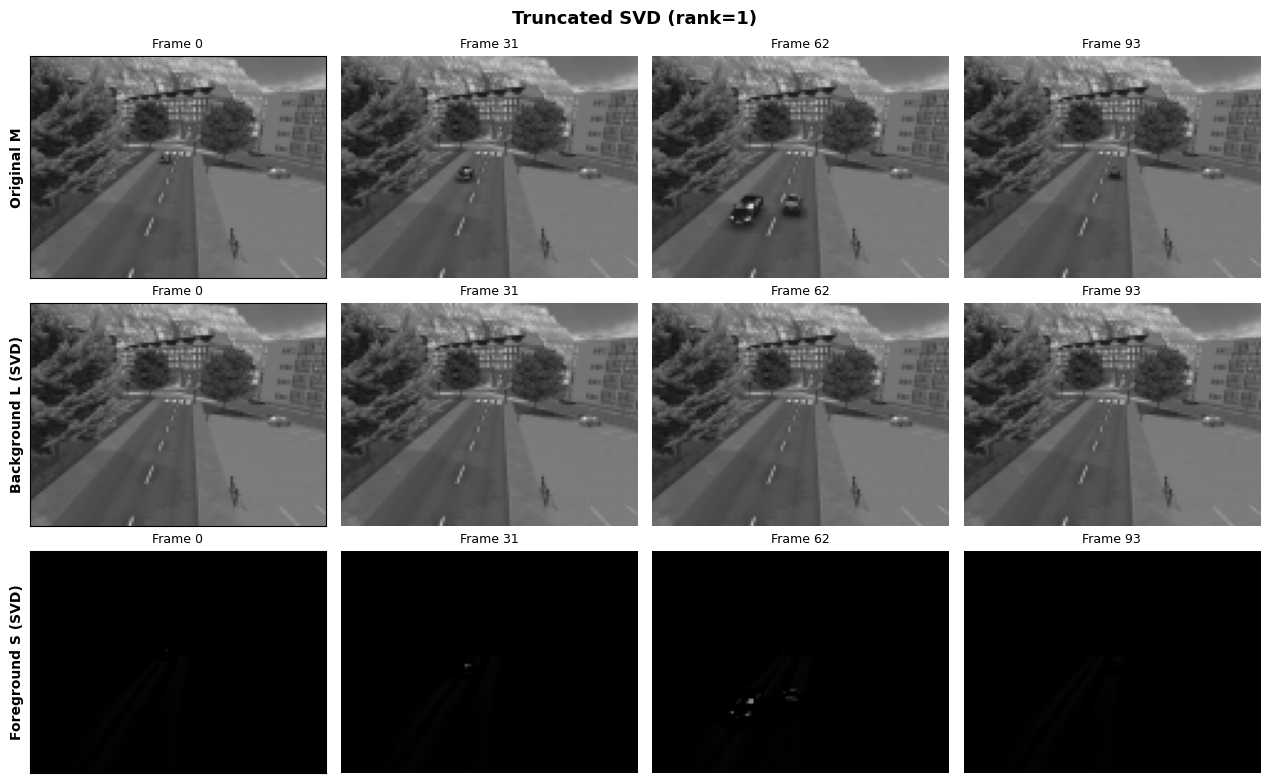

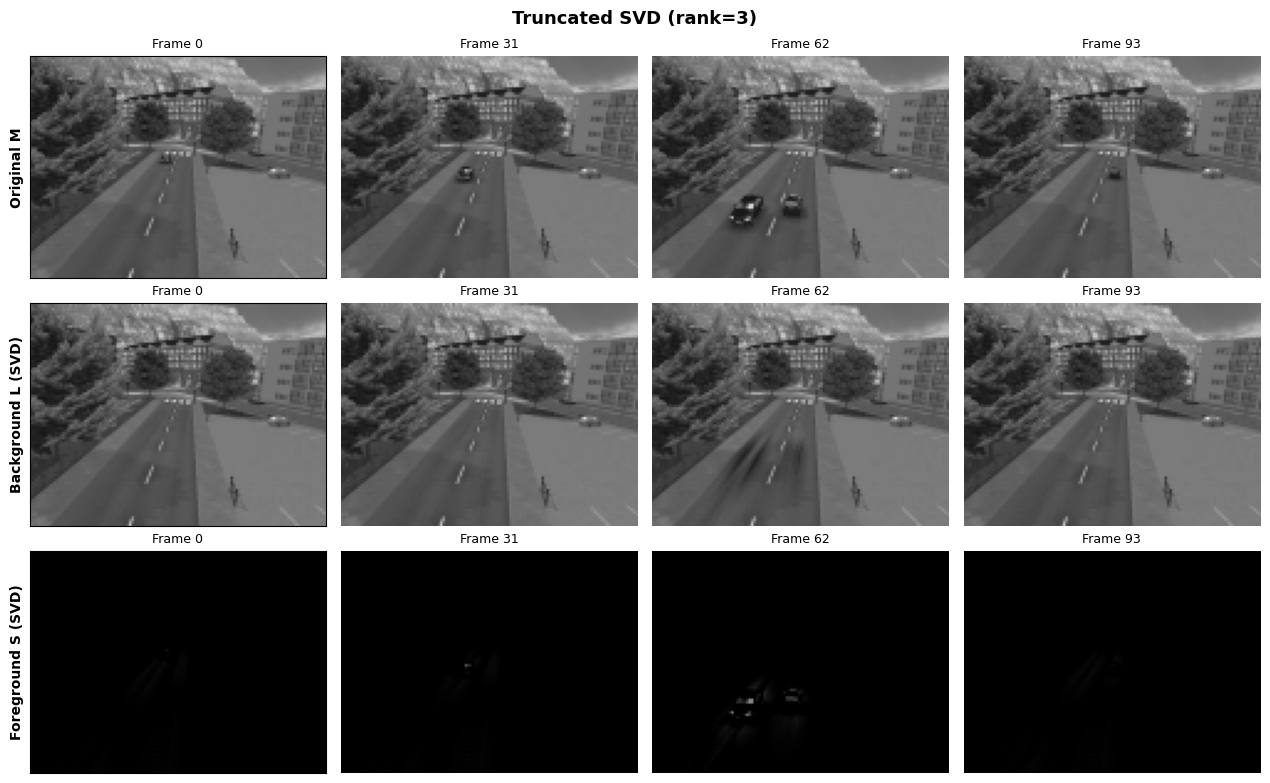

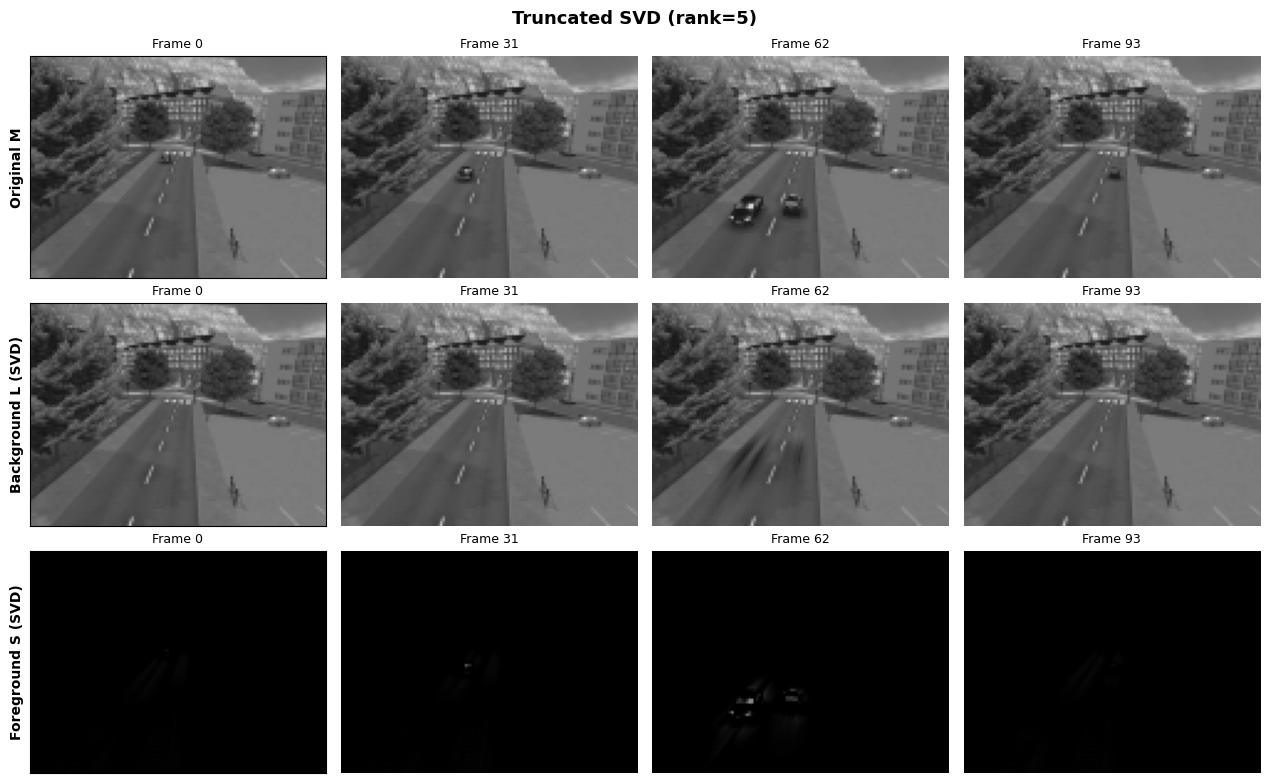

In [14]:
#Rank sweep to illustrate the background/ghosting trade-off (k=1, 3, 5)
svd_sweep_sim = run_svd_rank_sweep(M_sim, CFG, ranks=[1, 3, 5])

# Selected rank used for the head-to-head comparison below.
# k=3 balances background cleanliness against ghosting 
SVD_RANK = 3
svd_sim = svd_sweep_sim[SVD_RANK]


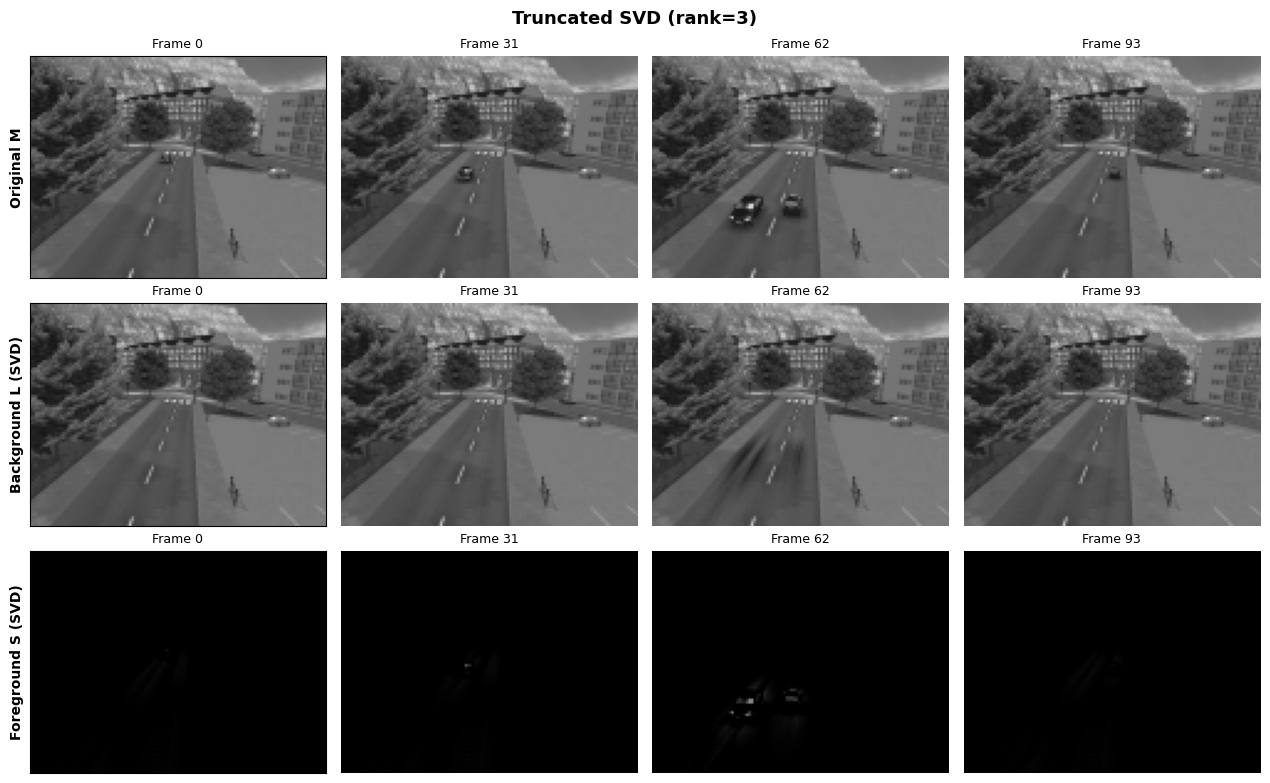

15:57:38 - INFO - -------------------------------------------------------
15:57:38 - INFO - Metrics [SVD - Simulated]
15:57:38 - INFO -   Frobenius error : 0.042754
15:57:38 - INFO -   MSE             : 0.000099
15:57:38 - INFO -   PSNR            : 42.26 dB
15:57:38 - INFO -   SSIM            : 0.9870
15:57:38 - INFO - -------------------------------------------------------


<Figure size 640x480 with 0 Axes>

In [15]:
visualize_svd_result(svd_sim, M_sim, CFG)
svd_metrics_sim = compute_metrics(M_sim, svd_sim.L, CFG, label="SVD - Simulated")
plt.savefig('SVD_sim_data_rank3.png')

### 4a. Ground Truth Evaluation - Simulated Data

15:57:39 - INFO - Loaded cached GT matrix: G_simulated.npy | shape=(10800, 125)


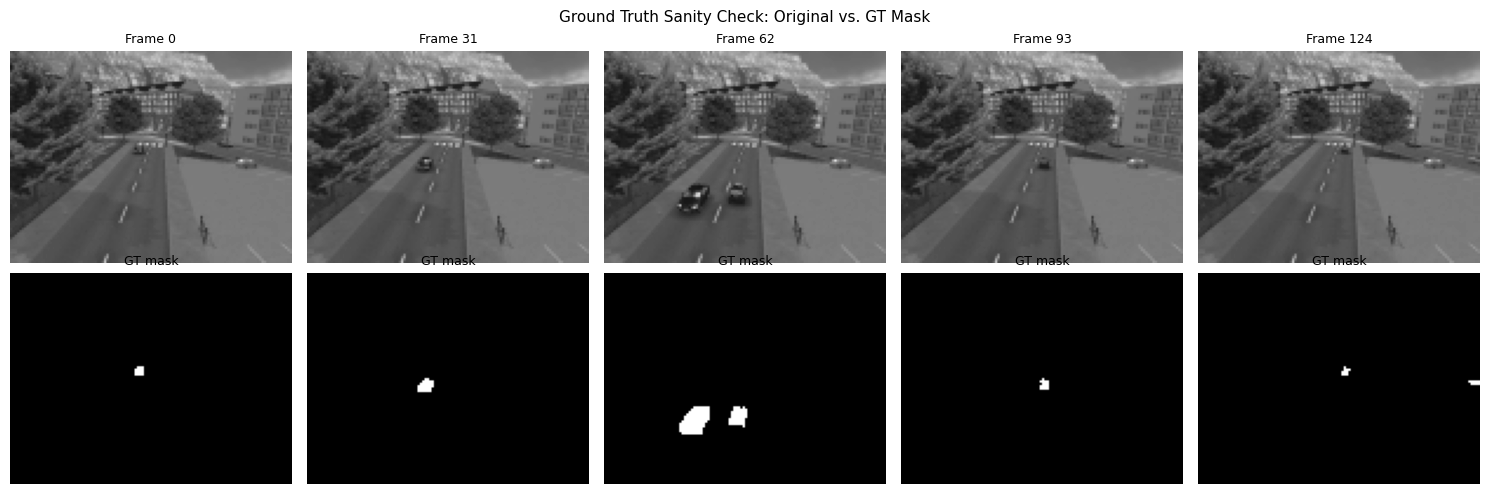

15:57:39 - INFO - GT shape matches M. Foreground fraction: 0.0086


In [16]:
# Load GT for the simulated video (same time window as M_sim)
G_sim = extract_gt_frames(
    GT_CFG.gt_video_path, CFG, cache_name="G_simulated.npy",
    target_n_frames=M_sim.shape[1],
)
inspect_gt(G_sim, M_sim, CFG)


In [17]:
sim_gt = compute_gt_metrics(
    svd_sim.S, G_sim,
    label="Truncated SVD - Simulated"
)

15:57:39 - INFO - =======================================================
15:57:39 - INFO - GT Metrics [Truncated SVD - Simulated]
15:57:39 - INFO -   Otsu threshold : 0.1804
15:57:39 - INFO -   Precision      : 0.6256
15:57:39 - INFO -   Recall         : 0.0573
15:57:39 - INFO -   F1-score       : 0.1036
15:57:39 - INFO -   Specificity    : 1.0000
15:57:39 - INFO -   Accuracy       : 0.9922
15:57:39 - INFO - =======================================================


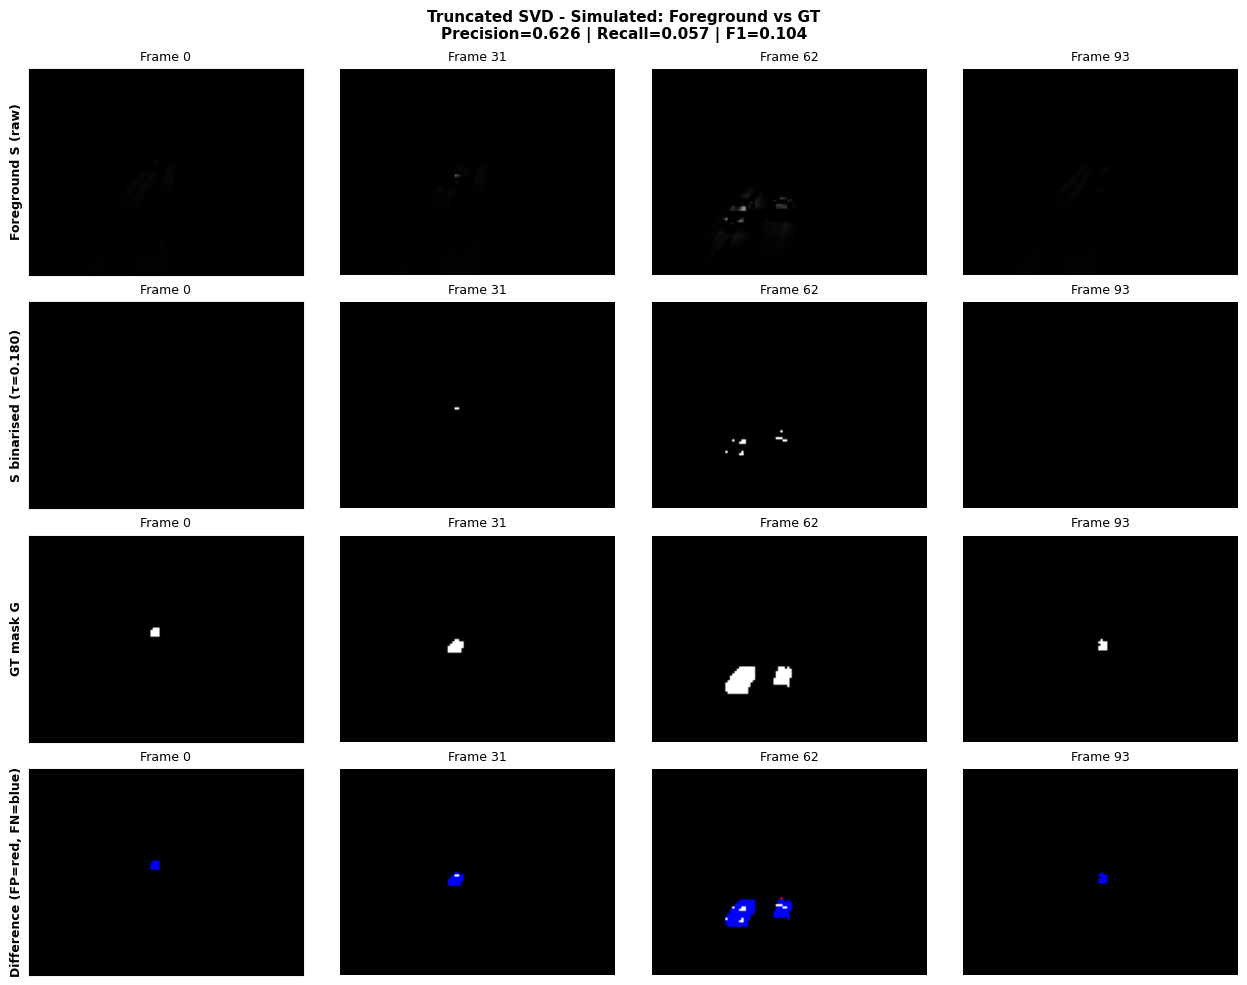

<Figure size 640x480 with 0 Axes>

In [18]:
visualize_gt_comparison(
    svd_sim.S, G_sim, sim_gt, CFG,
    title="Truncated SVD - Simulated: Foreground vs GT"
)
plt.savefig('SVD_sim_data_Foreground_GT.png')

## 5. Generalization: Run on Real Data

Same preprocessing, same rank, same metrics are applied to a real-world video to test whether the low-rank assumption still holds outside the synthetic benchmark.

15:57:40 - INFO - Loaded cached matrix: M_real.npy | shape=(10800, 50)
15:57:40 - INFO - ==================================================
15:57:40 - INFO - Real Data - Observation Matrix M | shape=(10800, 50) | dtype=float32
15:57:40 - INFO - Min/max: 0.0784 / 0.9922 | Mean/std: 0.4620 / 0.1674
15:57:40 - INFO - Estimated rank (90% variance): 1 | (99% variance): 1
15:57:40 - INFO - ==================================================


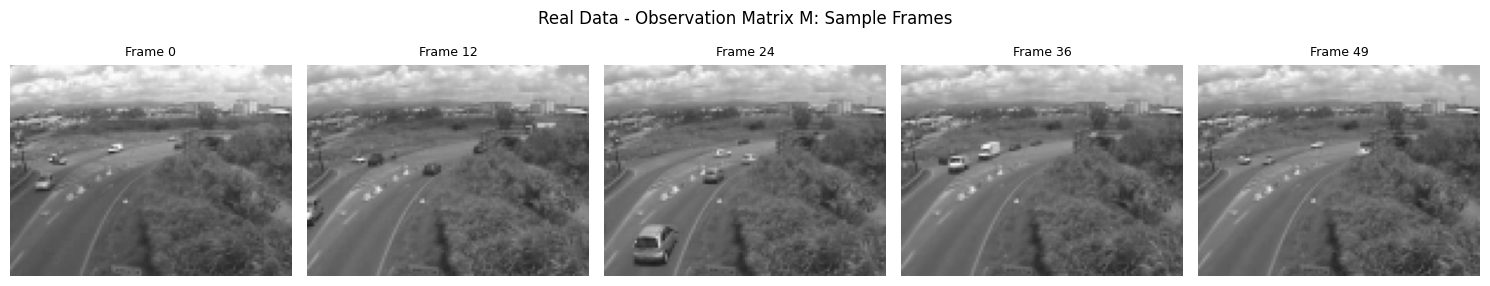

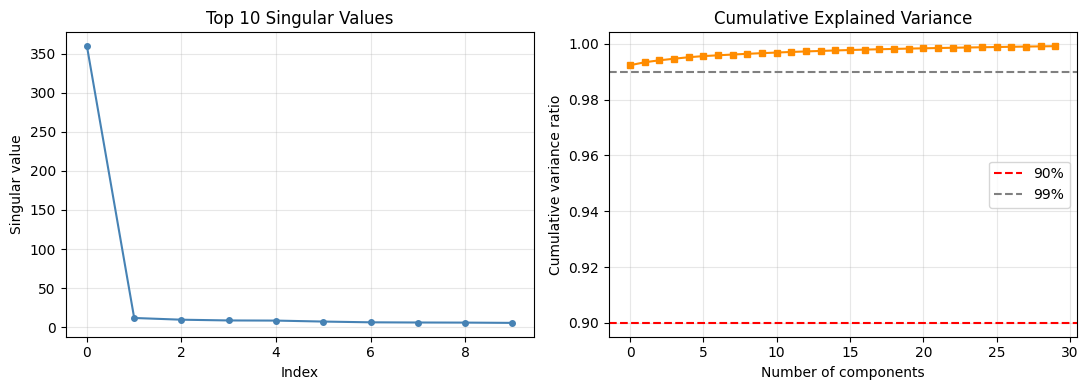

In [19]:
M_real = extract_frames(CFG.real_video_path, CFG, cache_name="M_real.npy")
inspect_matrix(M_real, CFG, title="Real Data - Observation Matrix M")


15:57:41 - INFO - Truncated SVD | rank=3 | Frobenius error=0.0770 | time=0.02s


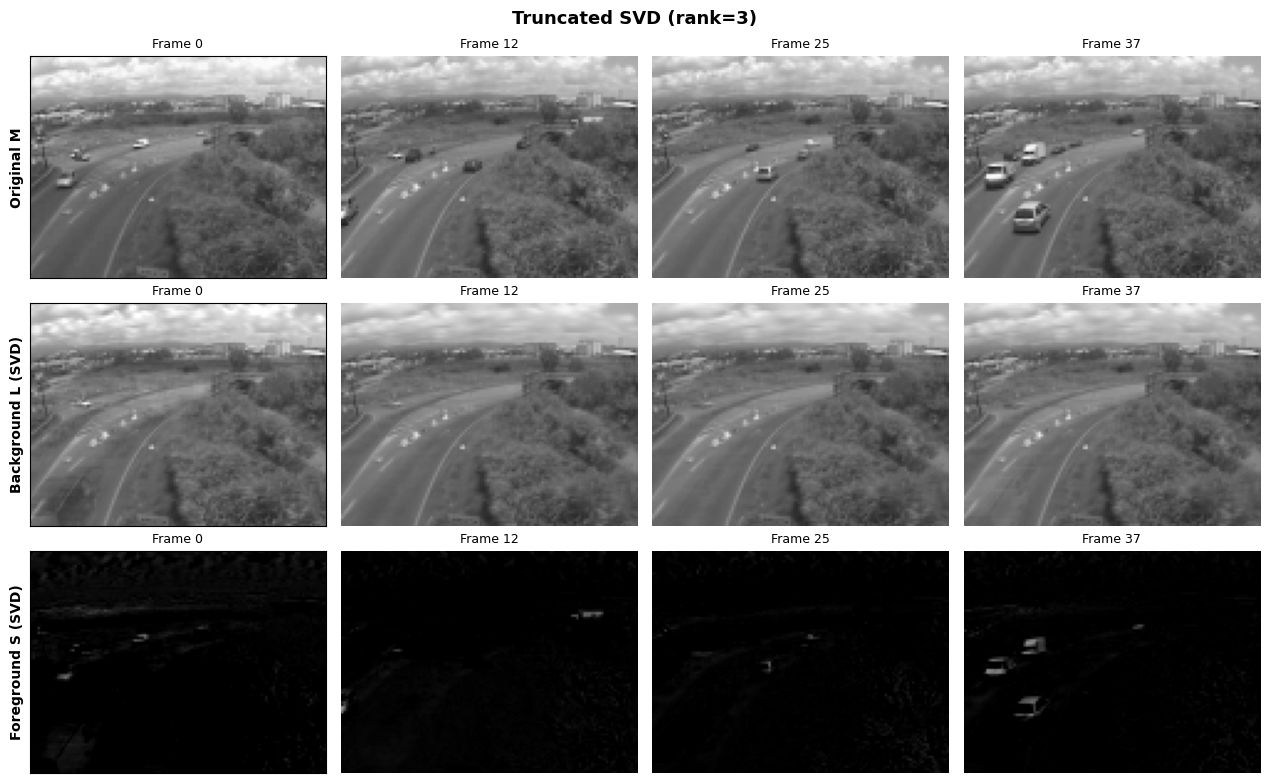

15:57:41 - INFO - -------------------------------------------------------
15:57:41 - INFO - Metrics [SVD - Real (generalization)]
15:57:41 - INFO -   Frobenius error : 0.077012
15:57:41 - INFO -   MSE             : 0.004426
15:57:41 - INFO -   PSNR            : 23.76 dB
15:57:41 - INFO -   SSIM            : 0.8362
15:57:41 - INFO - -------------------------------------------------------


<Figure size 640x480 with 0 Axes>

In [20]:
svd_real = truncated_svd(M_real, SVD_RANK)
visualize_svd_result(svd_real, M_real, CFG)
svd_metrics_real = compute_metrics(M_real, svd_real.L, CFG, label="SVD - Real (generalization)")
plt.savefig('SVD_real_data_rank3.png')

### 5a. Ground Truth Evaluation - Real (Generalization) Data

> **Note:** Ground truth here is the same GT mask video extracted
> over the same time window. If no GT is available for the real
> video, set a separate `gt_real_video_path` in GTConfig and
> replace `GT_CFG.gt_video_path` below, or skip this block.

15:57:41 - INFO - Loaded cached GT matrix: G_real.npy | shape=(10800, 125)
15:57:41 - WARNING - GT has 125 frames but observation matrix has 50 - trimming 75 trailing GT frames.


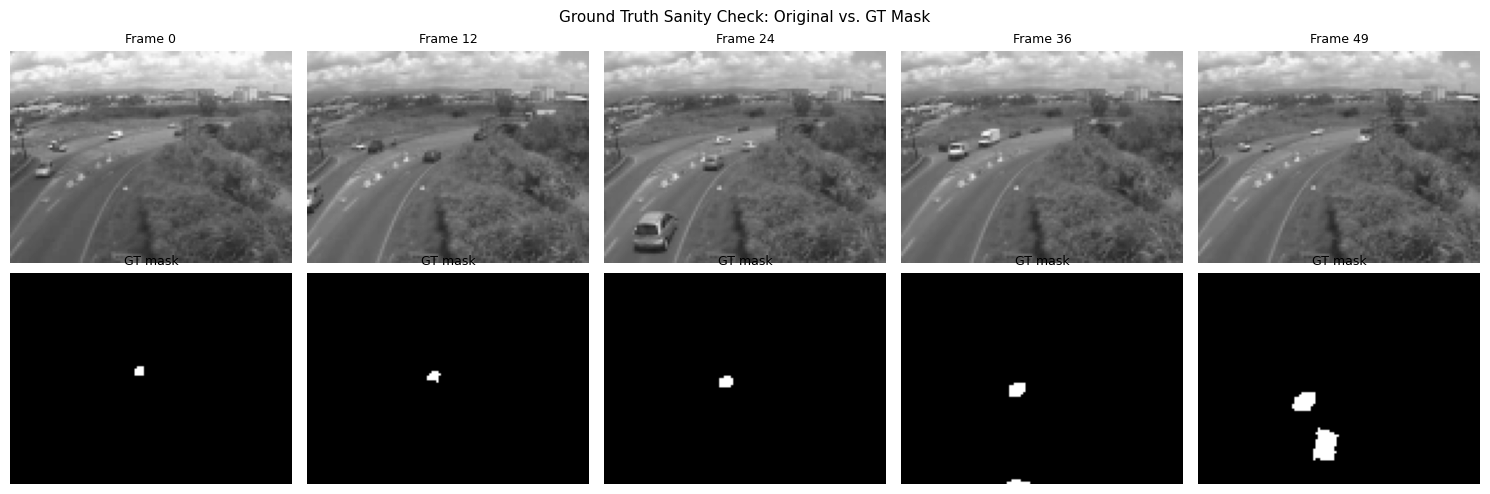

15:57:42 - INFO - GT shape matches M. Foreground fraction: 0.0055


In [21]:
# Load GT for the real video (same time window as M_real)
G_real = extract_gt_frames(
    GT_CFG.gt_video_path, CFG, cache_name="G_real.npy",
    target_n_frames=M_real.shape[1],
)
inspect_gt(G_real, M_real, CFG)


In [22]:
real_gt = compute_gt_metrics(
    svd_real.S, G_real,
    label="Truncated SVD - Real"
)

15:57:42 - INFO - =======================================================
15:57:42 - INFO - GT Metrics [Truncated SVD - Real]
15:57:42 - INFO -   Otsu threshold : 0.1529
15:57:42 - INFO -   Precision      : 0.0105
15:57:42 - INFO -   Recall         : 0.0110
15:57:42 - INFO -   F1-score       : 0.0089
15:57:42 - INFO -   Specificity    : 0.9943
15:57:42 - INFO -   Accuracy       : 0.9889
15:57:42 - INFO - =======================================================


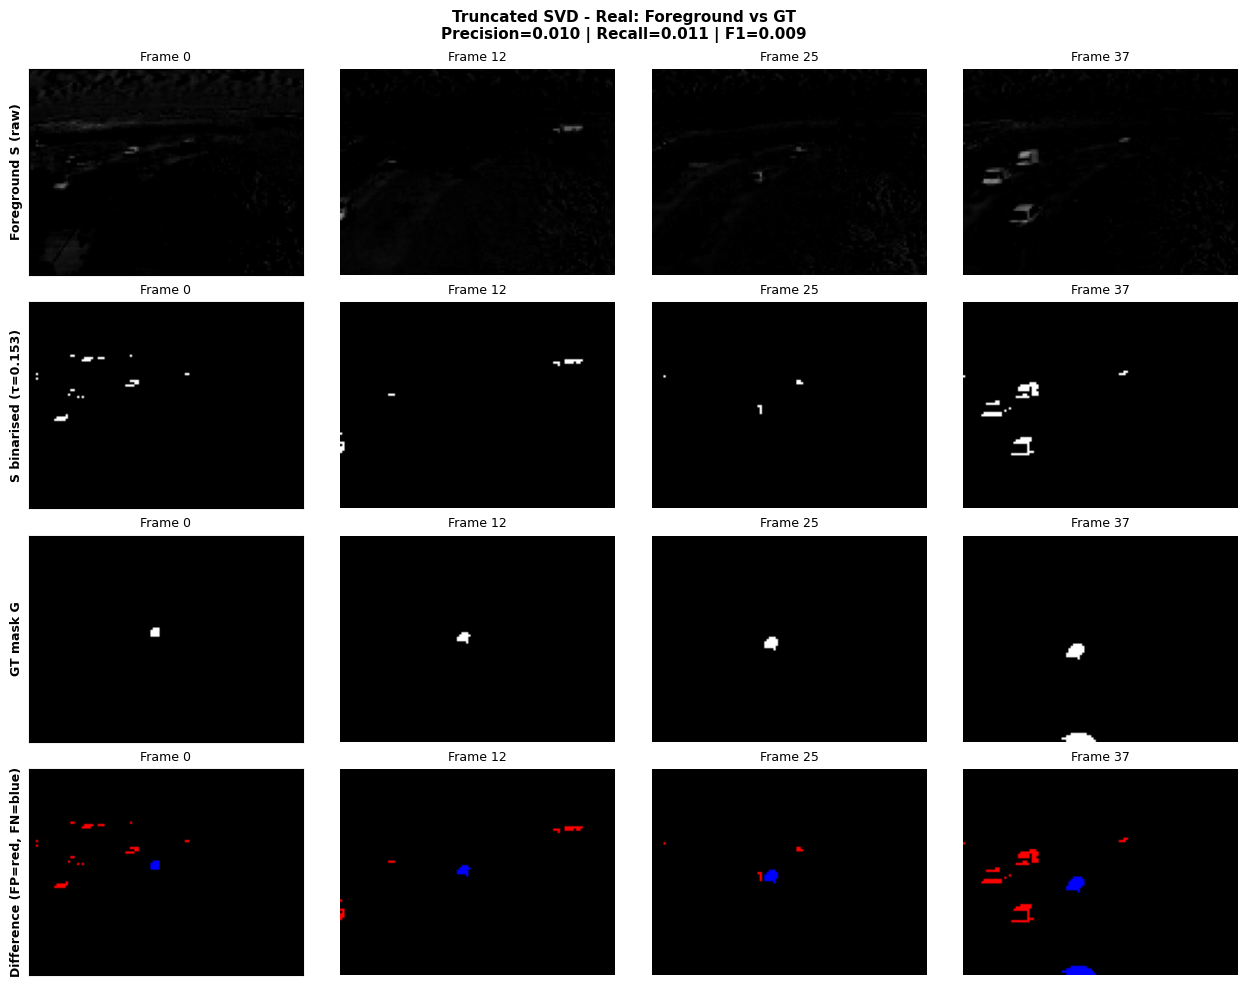

<Figure size 640x480 with 0 Axes>

In [23]:
visualize_gt_comparison(
    svd_real.S, G_real, real_gt, CFG,
    title="Truncated SVD - Real: Foreground vs GT"
)
plt.savefig('SVD_real_data_Foreground_GT.png')

## 6. Simulated vs. Generalization: Metrics Comparison

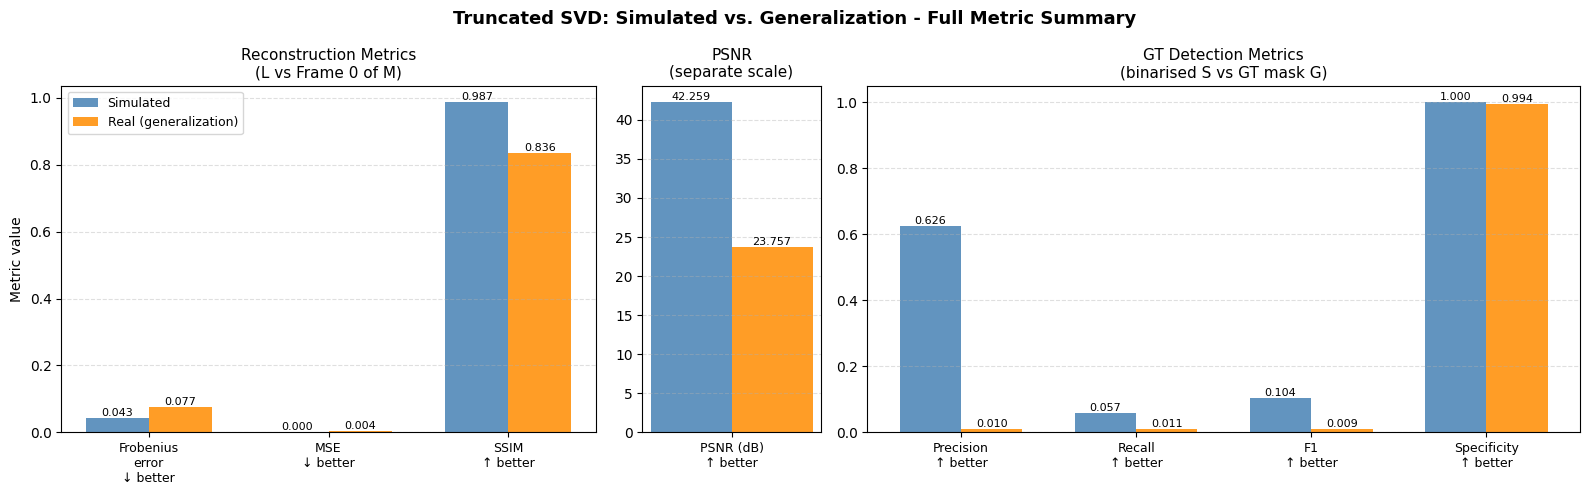

<Figure size 640x480 with 0 Axes>

In [24]:
# ============================================================
# Summary: Reconstruction Metrics vs GT Detection Metrics
#
# Left panel : Frobenius error, MSE, SSIM (reconstruction of L
#              vs Frame 0 of M - proxy background reference).
# Centre panel: PSNR (separate scale).
# Right panel : Precision, Recall, F1, Specificity (foreground
#               detection of S vs binary GT mask G).
#
# These two groups measure different things and should NOT be
# directly compared to each other - they are shown together
# only as a complete picture of method performance.
# ============================================================

def plot_full_comparison(
    svd_metrics_sim:    "MetricsResult",
    svd_metrics_real:   "MetricsResult",
    sim_gt:         GTMetricsResult,
    real_gt:        GTMetricsResult,
    cfg:            Config,
) -> None:
    """Three-panel figure: reconstruction metrics | PSNR | GT detection metrics."""

    recon_entries = [
        ("Frobenius\nerror", svd_metrics_sim.frobenius_error,
         svd_metrics_real.frobenius_error, False),
        ("MSE",   svd_metrics_sim.mse,    svd_metrics_real.mse,    False),
    ]
    if svd_metrics_sim.ssim is not None and svd_metrics_real.ssim is not None:
        recon_entries.append(("SSIM", svd_metrics_sim.ssim, svd_metrics_real.ssim, True))

    psnr_entry = ("PSNR (dB)", svd_metrics_sim.psnr_db, svd_metrics_real.psnr_db, True)

    gt_entries = [
        ("Precision",   sim_gt.precision,   real_gt.precision,   True),
        ("Recall",      sim_gt.recall,      real_gt.recall,      True),
        ("F1",          sim_gt.f1,          real_gt.f1,          True),
        ("Specificity", sim_gt.specificity, real_gt.specificity, True),
    ]

    fig, axes = plt.subplots(
        1, 3, figsize=(16, 5),
        gridspec_kw={"width_ratios": [len(recon_entries), 1, len(gt_entries)]},
    )

    colors = {"sim": "steelblue", "real": "darkorange"}

    def _draw(ax, entries, title, ylabel=None):
        x     = np.arange(len(entries))
        width = 0.35
        bars_sim  = ax.bar(x - width/2,
                           [e[1] for e in entries], width,
                           label="Simulated", color=colors["sim"], alpha=0.85)
        bars_real = ax.bar(x + width/2,
                           [e[2] for e in entries], width,
                           label="Real (generalization)",
                           color=colors["real"], alpha=0.85)
        for bar in list(bars_sim) + list(bars_real):
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, h,
                    f"{h:.3f}", ha="center", va="bottom", fontsize=8)
        tick_labels = [
            f"{e[0]}\n{'↑ better' if e[3] else '↓ better'}"
            for e in entries
        ]
        ax.set_xticks(x)
        ax.set_xticklabels(tick_labels, fontsize=9)
        ax.set_title(title, fontsize=11)
        ax.grid(axis="y", linestyle="--", alpha=0.4)
        if ylabel:
            ax.set_ylabel(ylabel)

    _draw(axes[0], recon_entries,
          "Reconstruction Metrics\n(L vs Frame 0 of M)", ylabel="Metric value")
    _draw(axes[1], [psnr_entry], "PSNR\n(separate scale)")
    _draw(axes[2], gt_entries,
          "GT Detection Metrics\n(binarised S vs GT mask G)")

    axes[0].legend(fontsize=9)
    fig.suptitle(
        "Truncated SVD: Simulated vs. Generalization - Full Metric Summary",
        fontsize=13, fontweight="bold",
    )
    plt.tight_layout()
    plt.show()


plot_full_comparison(
    svd_metrics_sim, svd_metrics_real,
    sim_gt, real_gt, CFG
)
plt.savefig('SVD_sim_real_data_comparison.png')

In [25]:
# ============================================================
# Full metrics table: reconstruction + GT detection
# ============================================================

print("=" * 70)
print(f"  {'Truncated SVD':^68}")
print("=" * 70)
print(f"{'':<22}{' Simulated':>16}{' Real (generalization)':>22}")
print("-" * 70)

# Reconstruction metrics (L vs Frame 0 proxy)
for name, sv, rv in [
    ("Frobenius error",  svd_metrics_sim.frobenius_error, svd_metrics_real.frobenius_error),
    ("MSE",              svd_metrics_sim.mse,              svd_metrics_real.mse),
    ("PSNR (dB)",        svd_metrics_sim.psnr_db,          svd_metrics_real.psnr_db),
]:
    print(f"{name:<22}{sv:>16.4f}{rv:>22.4f}")

ssim_s = f"{svd_metrics_sim.ssim:.4f}"  if svd_metrics_sim.ssim  is not None else "N/A"
ssim_r = f"{svd_metrics_real.ssim:.4f}" if svd_metrics_real.ssim is not None else "N/A"
print(f"{'SSIM':<22}{ssim_s:>16}{ssim_r:>22}")

print()
print("  -- GT Detection Metrics (binarised S vs GT mask) --")
print("-" * 70)
for name, sv, rv in [
    ("Otsu threshold",   sim_gt.threshold,   real_gt.threshold),
    ("Precision",        sim_gt.precision,   real_gt.precision),
    ("Recall",           sim_gt.recall,      real_gt.recall),
    ("F1-score",         sim_gt.f1,          real_gt.f1),
    ("Specificity",      sim_gt.specificity, real_gt.specificity),
]:
    print(f"{name:<22}{sv:>16.4f}{rv:>22.4f}")
print("=" * 70)


                             Truncated SVD                            
                             Simulated Real (generalization)
----------------------------------------------------------------------
Frobenius error                 0.0428                0.0770
MSE                             0.0001                0.0044
PSNR (dB)                      42.2588               23.7572
SSIM                            0.9870                0.8362

  -- GT Detection Metrics (binarised S vs GT mask) --
----------------------------------------------------------------------
Otsu threshold                  0.1804                0.1529
Precision                       0.6256                0.0105
Recall                          0.0573                0.0110
F1-score                        0.1036                0.0089
Specificity                     1.0000                0.9943


## 7. Takeaways

- **Reconstruction error (Frobenius/MSE/PSNR) is the metric SVD is built to optimize**, by the
  Eckart -Young theorem, no other rank-$k$ matrix can beat it on these. Low Frobenius error here is
  expected.
- A drop in PSNR/SSIM and a rise in MSE/Frobenius error from simulated to real data indicates the
  real video's background is less stationary (lighting changes, camera shake, more motion) than the
  synthetic scene i.e. the low-rank assumption holds less well.
- Watch the **foreground (S) panels** in the visualizations above, not just the numbers, SVD
  typically leaves visible ghosting of moving objects in the background L, since nothing in the
  objective penalizes that. This motivates the PCA and Robust PCA notebooks.
